In [6]:
import os
os.chdir('../')
import warnings

In [7]:
import torch

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
torch.cuda.is_available()

True

In [9]:
import scanpy as sc
import scarches as sca
from scarches.dataset.trvae.data_handling import remove_sparsity
import matplotlib.pyplot as plt
import numpy as np
import gdown

 captum (see https://github.com/pytorch/captum).
INFO:lightning_fabric.utilities.seed:Global seed set to 0
/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/flax/core/frozen_dict.py:169: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(


In [10]:
sc.settings.set_figure_params(dpi=200, frameon=False)
sc.set_figure_params(dpi=200)
sc.set_figure_params(figsize=(4, 4))
torch.set_printoptions(precision=3, sci_mode=False, edgeitems=7)

In [11]:
main_dir = '/home/wergillius/Project/diffuse_differentiate'

# read in TF 

In [12]:
# differentiated TF-atlas
adata_dTF = sc.read_h5ad(f"{main_dir}/data/TFAtlas/GSE217460_210322_TFAtlas_differentiated.h5ad")

In [13]:
adata_dTF

AnnData object with n_obs × n_vars = 28825 × 4806
    obs: 'TF', 'batch', 'louvain', 'n_counts', 'n_genes', 'percent_mito'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'diffmap_evals', 'hvg', 'iroot', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


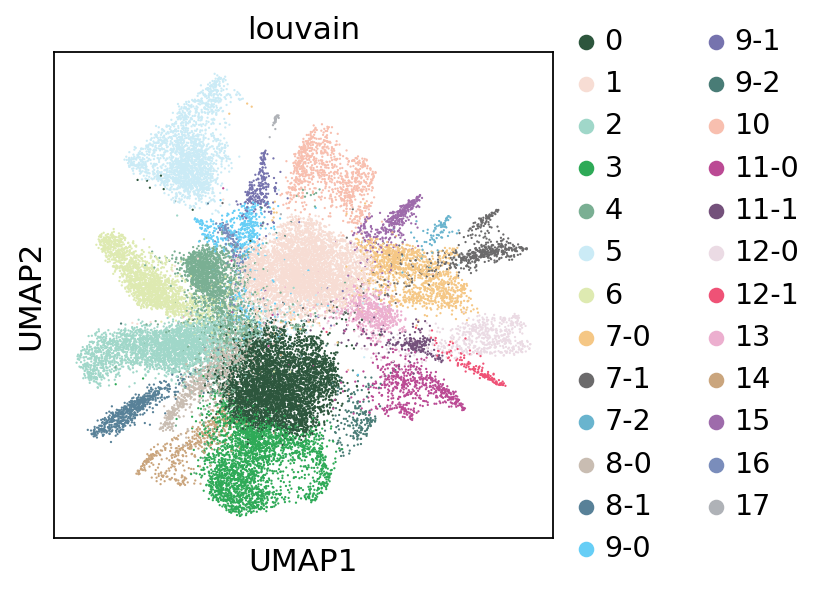

In [14]:
sc.pl.umap(adata_dTF, color=['louvain'])

In [37]:
# differentiated TF-atlas
adata_subTF = sc.read_h5ad(f"{main_dir}/data/TFAtlas/GSE217460_210322_TFAtlas_subsample.h5ad")

In [38]:
adata_subTF

AnnData object with n_obs × n_vars = 671453 × 3517
    obs: 'TF', 'batch', 'louvain', 'n_counts', 'n_genes', 'percent_mito', 'dpt_pseudotime', 'v_pseudotime'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'diffmap_evals', 'draw_graph', 'hvg', 'iroot', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'NMF', 'X_diffmap', 'X_draw_graph_fa', 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [38]:
adata_subTF

AnnData object with n_obs × n_vars = 671453 × 3517
    obs: 'TF', 'batch', 'louvain', 'n_counts', 'n_genes', 'percent_mito', 'dpt_pseudotime', 'v_pseudotime'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'diffmap_evals', 'draw_graph', 'hvg', 'iroot', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'NMF', 'X_diffmap', 'X_draw_graph_fa', 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

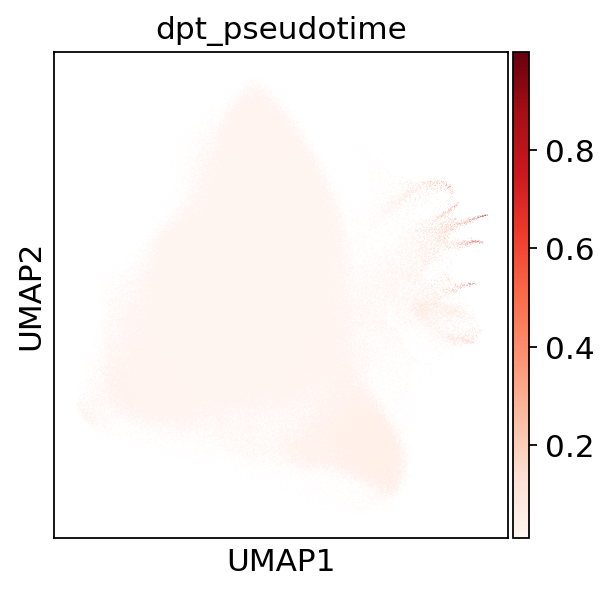

In [46]:
sc.pl.umap(adata_subTF, color=['dpt_pseudotime'], cmap='Reds')

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


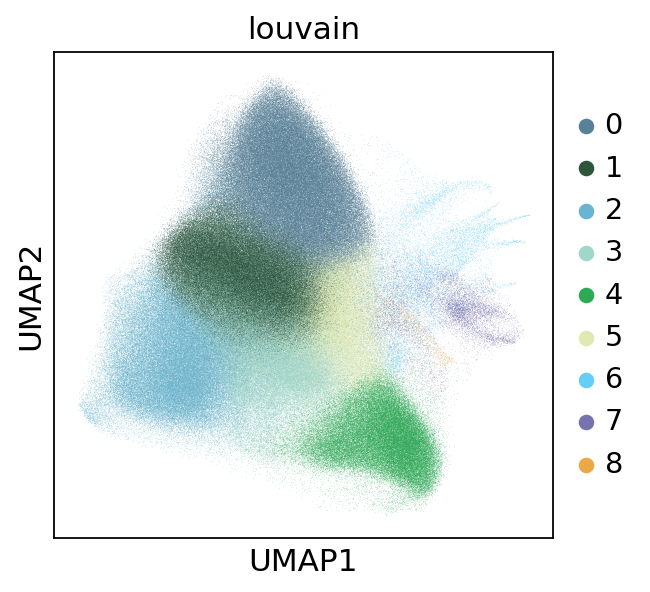

In [47]:
sc.pl.umap(adata_subTF, color=['louvain'])

# Mikkola data

In [16]:
# differentiated TF-atlas
adata_fig1_17 = sc.read_h5ad(f"{main_dir}/data/Mikkola/Fig1_17.h5ad")

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/anndata/compat/__init__.py:232: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(


In [17]:
adata_fig1_17.obs[['RNA_snn_res.0.6' , 'seurat_clusters']] = adata_fig1_17.obs[['RNA_snn_res.0.6' , 'seurat_clusters']].astype(str);

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


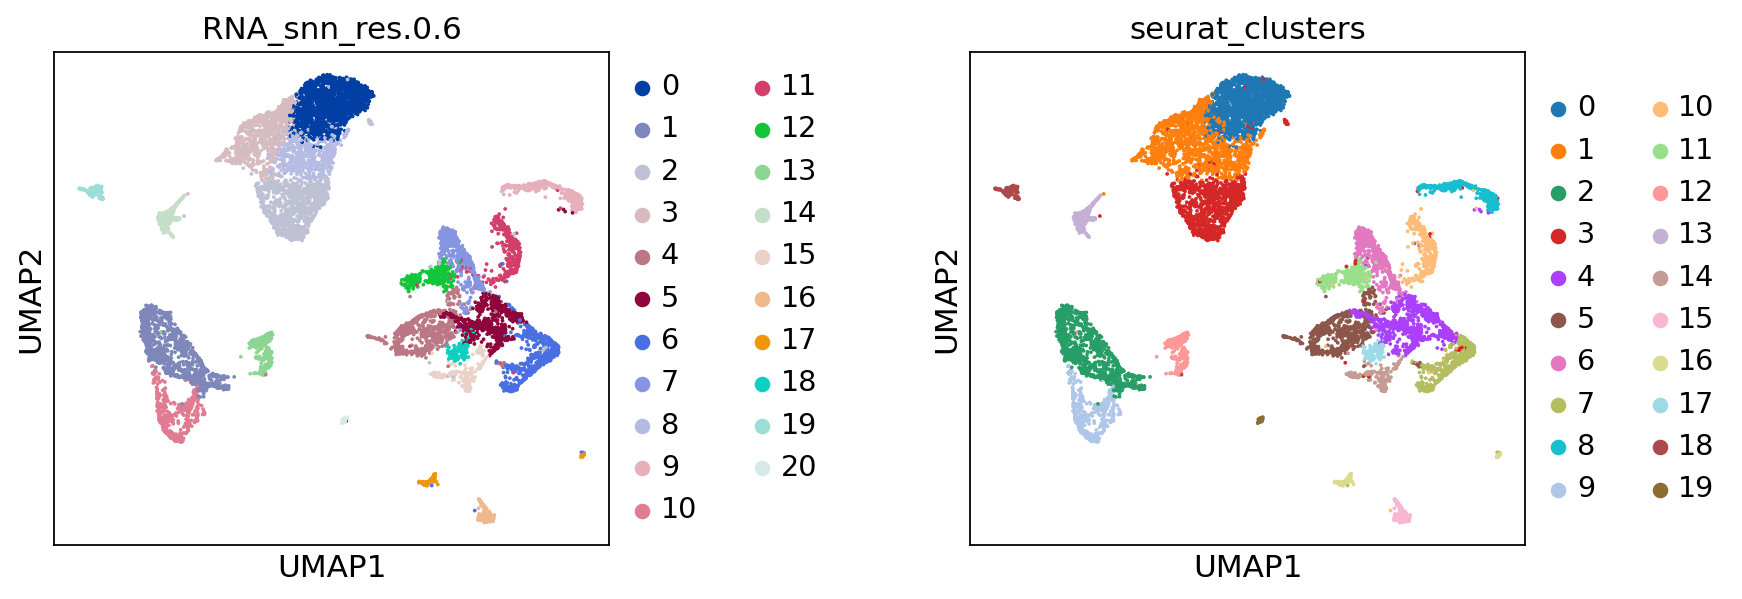

In [18]:
sc.pl.umap(adata_fig1_17, color=['RNA_snn_res.0.6' , 'seurat_clusters'], wspace=0.5)

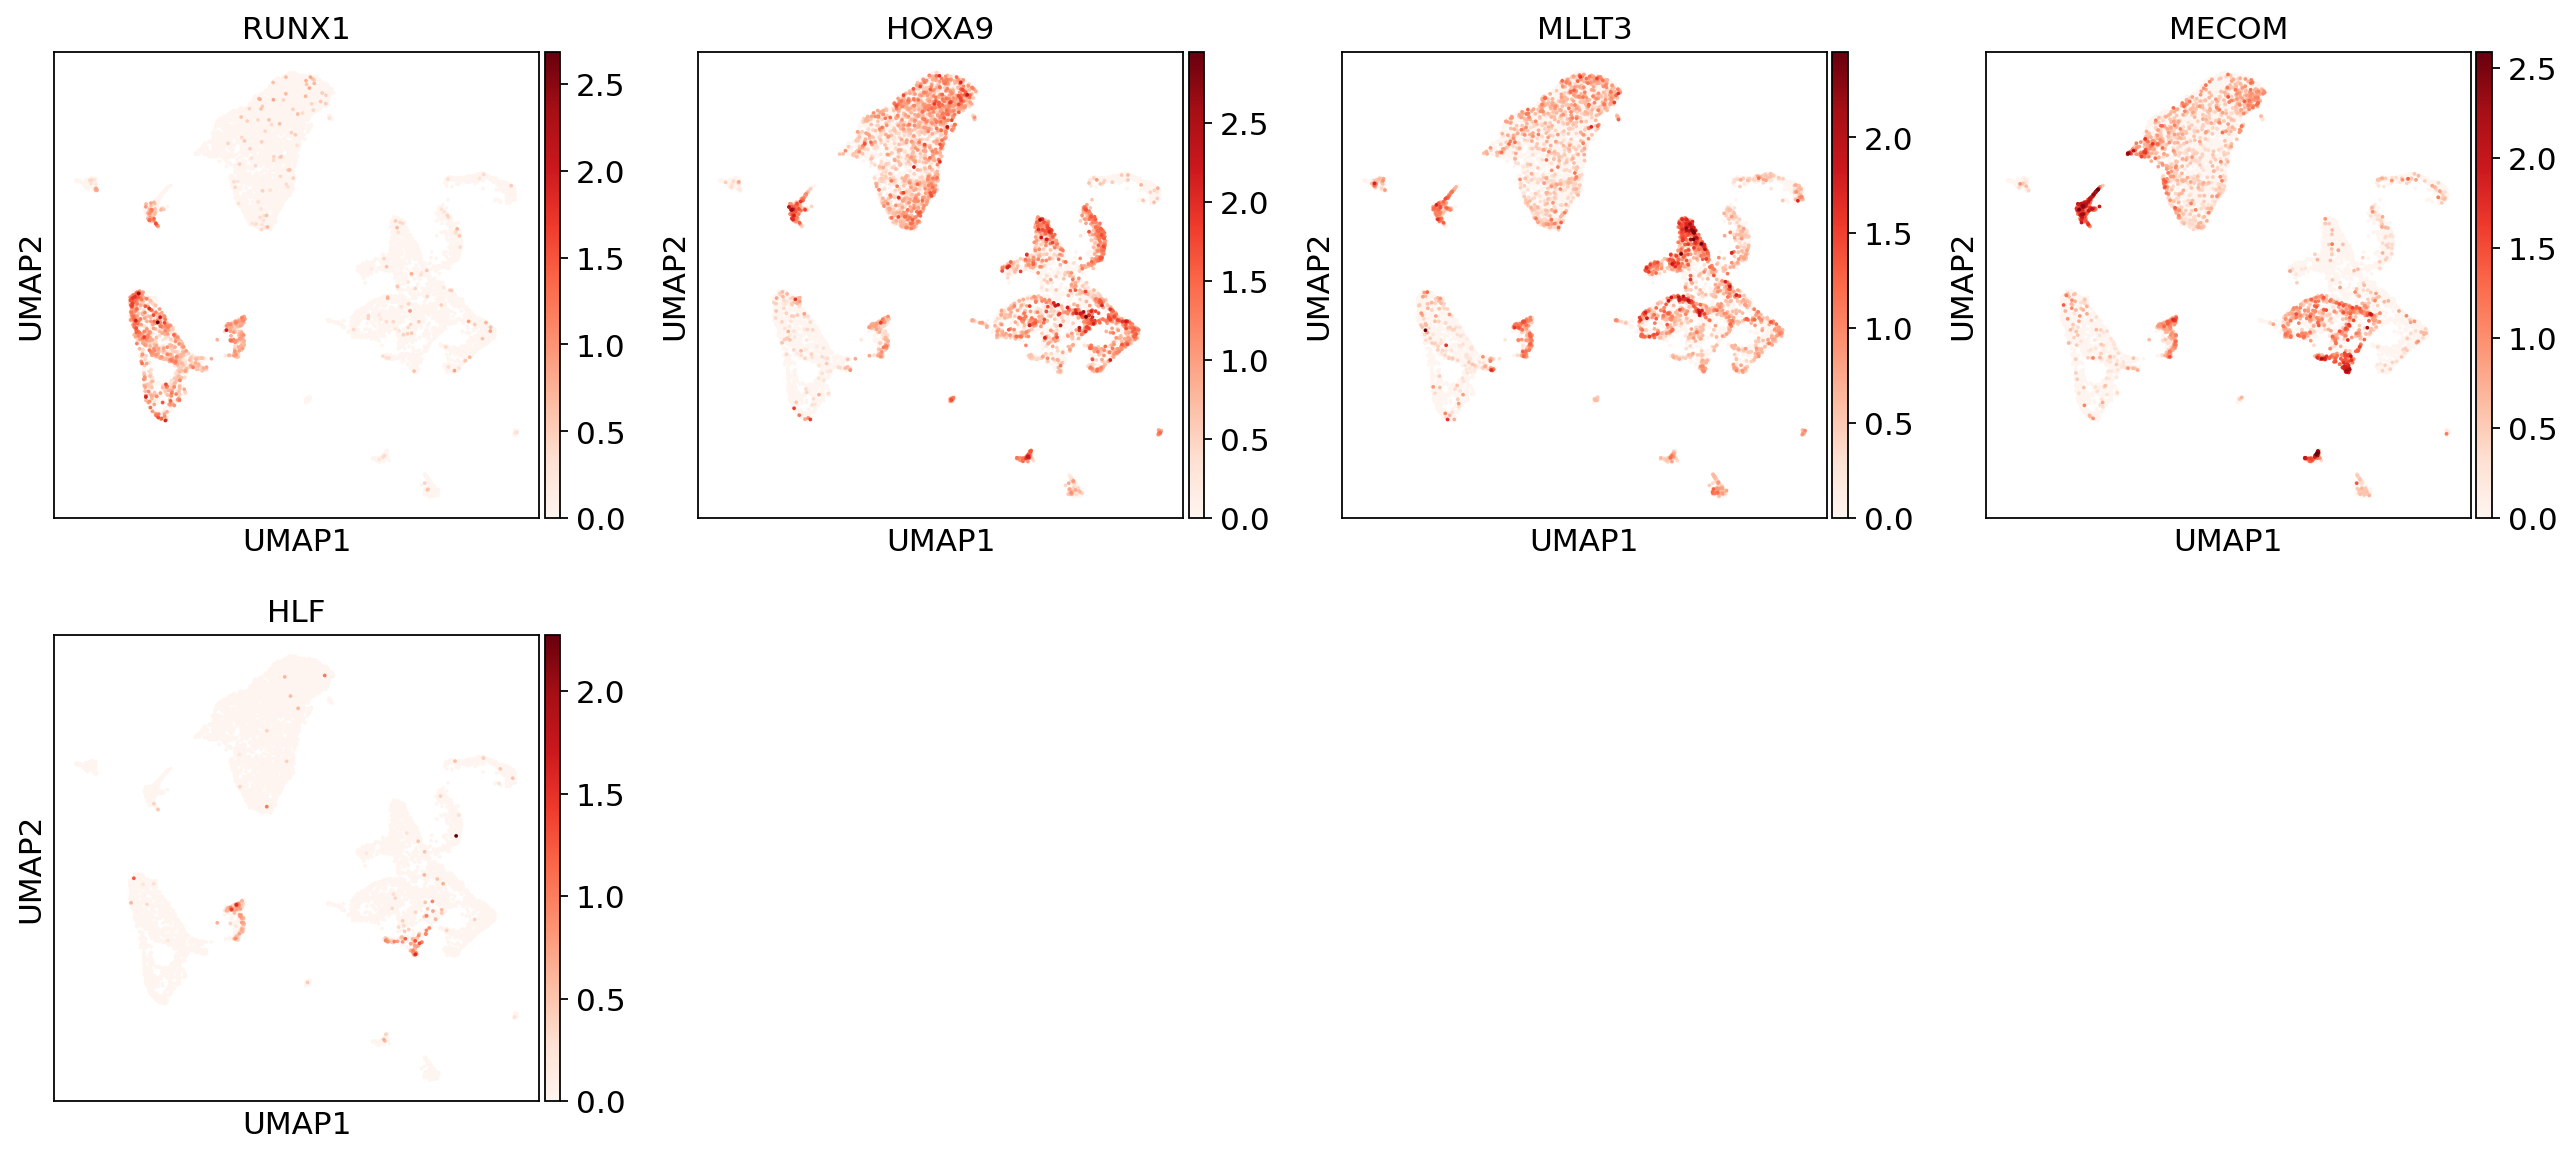

In [32]:
sc.pl.umap(adata_fig1_17, cmap='Reds', color=['RUNX1', 'HOXA9' , 'MLLT3', 'MECOM', 'HLF'])

# Load Fetal reference

In [23]:
import scanpy.external as sce

In [19]:
adata_int = adata_dTF.concatenate(adata_fig1_17, batch_categories=['TF_atlas', 'Mikkola_cs1415'])

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/anndata/_core/anndata.py:1785: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  [AnnData(sparse.csr_matrix(a.shape), obs=a.obs) for a in all_adatas],
/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/anndata/_core/anndata.py:1785: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  [AnnData(sparse.csr_matrix(a.shape), obs=a.obs) for a in all_adatas],


In [26]:
sce.pp.harmony_integrate(adata_int, 'batch')

2023-03-15 10:36:40,321 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
INFO:harmonypy:Computing initial centroids with sklearn.KMeans...
2023-03-15 10:36:47,328 - harmonypy - INFO - sklearn.KMeans initialization complete.
INFO:harmonypy:sklearn.KMeans initialization complete.
2023-03-15 10:36:47,547 - harmonypy - INFO - Iteration 1 of 10
INFO:harmonypy:Iteration 1 of 10
2023-03-15 10:37:02,234 - harmonypy - INFO - Iteration 2 of 10
INFO:harmonypy:Iteration 2 of 10
2023-03-15 10:37:18,853 - harmonypy - INFO - Iteration 3 of 10
INFO:harmonypy:Iteration 3 of 10
2023-03-15 10:37:35,110 - harmonypy - INFO - Iteration 4 of 10
INFO:harmonypy:Iteration 4 of 10
2023-03-15 10:37:52,163 - harmonypy - INFO - Iteration 5 of 10
INFO:harmonypy:Iteration 5 of 10
2023-03-15 10:38:07,517 - harmonypy - INFO - Iteration 6 of 10
INFO:harmonypy:Iteration 6 of 10
2023-03-15 10:38:21,812 - harmonypy - INFO - Iteration 7 of 10
INFO:harmonypy:Iteration 7 of 10
2023-03-15 10:38:31,901 - 

In [29]:
'X_pca_harmony' in adata_int.obsm

True

In [30]:
adata_int

AnnData object with n_obs × n_vars = 39313 × 577
    obs: 'TF', 'batch', 'louvain', 'n_counts', 'n_genes', 'percent_mito', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'RNA_snn_res.0.5', 'seurat_clusters', 'RNA_snn_res.0.6'
    var: 'vst.mean-Mikkola_cs1415', 'vst.variance-Mikkola_cs1415', 'vst.variance.expected-Mikkola_cs1415', 'vst.variance.standardized-Mikkola_cs1415', 'vst.variable-Mikkola_cs1415', 'highly_variable-TF_atlas', 'means-TF_atlas', 'dispersions-TF_atlas', 'dispersions_norm-TF_atlas', 'mean-TF_atlas', 'std-TF_atlas'
    obsm: 'X_pca', 'X_umap', 'X_pca_harmony'

In [33]:
sc.pp.neighbors(adata_int, use_rep='X_pca_harmony')
sc.tl.umap(adata_int)

In [34]:
adata_int

AnnData object with n_obs × n_vars = 39313 × 577
    obs: 'TF', 'batch', 'louvain', 'n_counts', 'n_genes', 'percent_mito', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'RNA_snn_res.0.5', 'seurat_clusters', 'RNA_snn_res.0.6'
    var: 'vst.mean-Mikkola_cs1415', 'vst.variance-Mikkola_cs1415', 'vst.variance.expected-Mikkola_cs1415', 'vst.variance.standardized-Mikkola_cs1415', 'vst.variable-Mikkola_cs1415', 'highly_variable-TF_atlas', 'means-TF_atlas', 'dispersions-TF_atlas', 'dispersions_norm-TF_atlas', 'mean-TF_atlas', 'std-TF_atlas'
    uns: 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap', 'X_pca_harmony'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


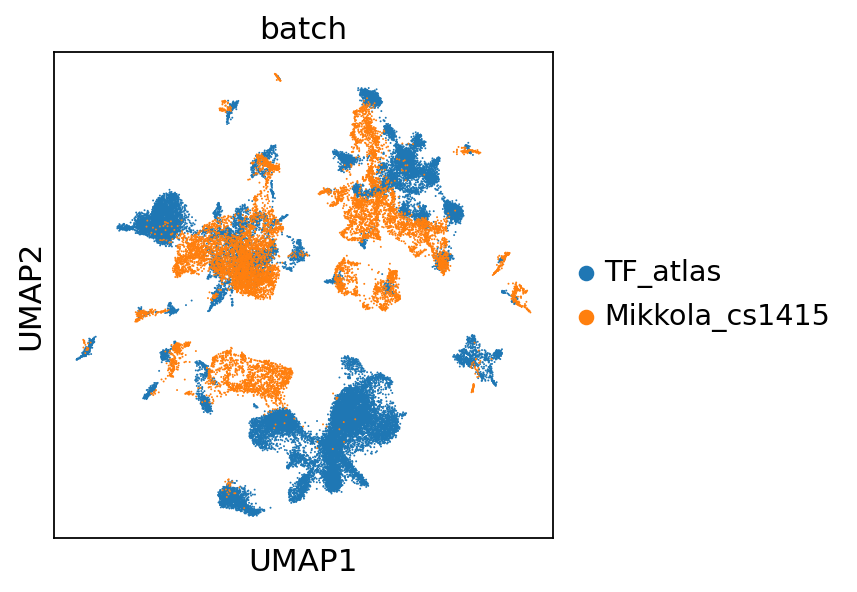

In [35]:
sc.pl.umap(adata_int, color=['batch'])